# 📍 Lección 1: Método científico y estadística



### 1. Definir el problema de investigación
- **Problema central:** ¿Qué factores influyen en los hábitos de sueño, alimentación y actividad física de los jóvenes universitarios?
- **Relevancia:** Estos hábitos impactan directamente en el rendimiento académico, la salud física y el bienestar emocional.

### 2. Formular hipótesis
- **Hipótesis nula (H₀):** No existe relación significativa entre los hábitos de sueño, alimentación y actividad física en jóvenes universitarios.
- **Hipótesis alternativa (H₁):** Sí existe relación significativa entre los hábitos de sueño, alimentación y actividad física en jóvenes universitarios.

### 3. Identificar variables relevantes
- **Cuantitativas:**
  - Horas promedio de sueño por día.
  - Número de comidas saludables por semana.
  - Minutos de actividad física semanal.
- **Cualitativas:**
  - Sexo.
  - Carrera universitaria.
  - Percepción subjetiva de bienestar (alta, media, baja).

### 4. Enfoque del método científico
- **Observación:** Identificar patrones de hábitos saludables en la población universitaria.
- **Planteamiento del problema:** Determinar si los hábitos de sueño, alimentación y actividad física están relacionados.
- **Hipótesis:** Ya formuladas.
- **Experimentación/Recopilación de datos:** Encuesta o simulación de dataset con al menos 100 registros.
- **Análisis:** Aplicar técnicas de inferencia estadística (intervalos de confianza, pruebas de hipótesis).
- **Conclusión:** Validar o rechazar hipótesis y proponer recomendaciones.

### 5. Diseño preliminar del estudio
- **Tipo de estudio:** Cuantitativo, transversal, descriptivo y correlacional.
- **Muestra:** Jóvenes universitarios de distintas carreras.
- **Instrumento:** Encuesta estructurada con preguntas cerradas y escala Likert.
- **Análisis:** Uso de software estadístico (Python).

---


In [ ]:
import pandas as pd
import numpy as np

# Semilla para reproducibilidad
np.random.seed(42)

# Número de registros
n = 100

# Variables simuladas
ID = np.arange(1, n+1)
Sexo = np.random.choice(['M', 'F'], size=n)
Edad = np.random.randint(18, 25, size=n)  # edades entre 18 y 24
Carrera = np.random.choice(['Salud', 'Ingeniería', 'Humanidades', 'Ciencias'], size=n)

# Horas de sueño ~ distribución normal (media=7, sd=1.2)
Horas_sueño = np.round(np.random.normal(7, 1.2, size=n), 1)
Horas_sueño = np.clip(Horas_sueño, 4.5, 10)  # límites razonables

# Comidas saludables por semana (discreta entre 3 y 15)
Comidas_saludables = np.random.randint(3, 16, size=n)

# Actividad física semanal en minutos (normal media=150, sd=60)
Actividad_física = np.round(np.random.normal(150, 60, size=n))
Actividad_física = np.clip(Actividad_física, 30, 300)

# Bienestar percibido (ordinal)
Bienestar_percibido = np.random.choice(['Alta', 'Media', 'Baja'], size=n, p=[0.4, 0.4, 0.2])

# Crear DataFrame
df = pd.DataFrame({
    'ID': ID,
    'Sexo': Sexo,
    'Edad': Edad,
    'Carrera': Carrera,
    'Horas_sueño': Horas_sueño,
    'Comidas_saludables': Comidas_saludables,
    'Actividad_física': Actividad_física,
    'Bienestar_percibido': Bienestar_percibido
})

# Mostrar primeras filas
print(df.head())

# Guardar en CSV si lo necesitas
df.to_csv("habitos_universitarios.csv", index=False)


   ID Sexo  Edad      Carrera  Horas_sueño  Comidas_saludables  \
0   1    M    24        Salud          5.4                  14   
1   2    F    19     Ciencias          6.2                   5   
2   3    M    19        Salud          6.8                   9   
3   4    M    21     Ciencias          8.7                  14   
4   5    M    19  Humanidades          6.9                   4   

   Actividad_física Bienestar_percibido  
0             150.0               Media  
1             195.0               Media  
2             266.0                Baja  
3             175.0                Baja  
4             184.0               Media  


Horas de sueño: simuladas con distribución normal centrada en 7 horas.

Comidas saludables: valores enteros entre 3 y 15.

Actividad física: minutos semanales, normal con media 150 y desviación 60.

Bienestar percibido: ordinal con mayor probabilidad de "Alta" y "Media".

# 📍 Lección 2: Probabilidad y estadística


1. Definir eventos aleatorios
Ejemplos de eventos en tu estudio:

A: Un estudiante duerme más de 7 horas diarias.

B: Un estudiante realiza más de 150 minutos de actividad física semanal.

C: Un estudiante reporta bienestar percibido “Alta”.

Estos eventos se pueden representar en árboles de probabilidad o diagramas de Venn para visualizar intersecciones y uniones.



2. Tipo de muestreo
Muestreo aleatorio simple: todos los estudiantes tienen la misma probabilidad de ser seleccionados.

Muestreo estratificado: dividir por carrera (Salud, Ingeniería, Humanidades, Ciencias) y tomar muestras proporcionales.
👉 Para tu caso, el estratificado es más recomendable, porque asegura representación de todas las carreras.

3. Simulación del diseño muestral
Ya tenemos el dataset de 100 registros. Puedes extraer una muestra de, por ejemplo, 30 estudiantes con muestreo aleatorio simple:

In [ ]:
# Muestreo aleatorio simple
muestra_simple = df.sample(n=30, random_state=1)

# Muestreo estratificado por carrera (ejemplo: 10 por cada carrera)
muestra_estratificada = df.groupby("Carrera", group_keys=False).apply(lambda x: x.sample(n=10, random_state=1))


/tmp/ipykernel_11914/2047292574.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  muestra_estratificada = df.groupby("Carrera", group_keys=False).apply(lambda x: x.sample(n=10, random_state=1))


4. Cálculo de probabilidades básicas

In [ ]:
# Probabilidad de que un estudiante duerma más de 7 horas
p_A = (df["Horas_sueño"] > 7).mean()

# Probabilidad de que un estudiante haga más de 150 min de actividad física
p_B = (df["Actividad_física"] > 150).mean()

# Probabilidad de bienestar percibido "Alta"
p_C = (df["Bienestar_percibido"] == "Alta").mean()

# Probabilidad conjunta (A ∩ B): duerme >7h y hace >150 min de actividad
p_AyB = ((df["Horas_sueño"] > 7) & (df["Actividad_física"] > 150)).mean()

# Probabilidad unión (A ∪ B): duerme >7h o hace >150 min
p_AoB = ((df["Horas_sueño"] > 7) | (df["Actividad_física"] > 150)).mean()

# Probabilidad complementaria de A (¬A): duerme ≤7h
p_notA = 1 - p_A

print("P(A) =", p_A)
print("P(B) =", p_B)
print("P(C) =", p_C)
print("P(A ∩ B) =", p_AyB)
print("P(A ∪ B) =", p_AoB)
print("P(¬A) =", p_notA)


P(A) = 0.48
P(B) = 0.53
P(C) = 0.43
P(A ∩ B) = 0.26
P(A ∪ B) = 0.75
P(¬A) = 0.52


Interpretación de resultados (ejemplo hipotético)
P(A) = 0.45 → 45% de los estudiantes duermen más de 7 horas.

P(B) = 0.40 → 40% realizan más de 150 min de actividad física.

P(C) = 0.38 → 38% reportan bienestar “Alta”.

P(A ∩ B) = 0.20 → 20% cumplen ambos hábitos saludables.

P(A ∪ B) = 0.65 → 65% cumplen al menos uno de los dos hábitos.

P(¬A) = 0.55 → 55% duermen 7 horas o menos.

# 📍 Lección 3: Distribución de probabilidad

1. Identificación de distribuciones
Horas de sueño (variable continua): se ajusta a una distribución normal (media ≈ 7 horas, desviación estándar ≈ 1.2).

Comidas saludables por semana (variable discreta): se ajusta a una distribución binomial (número de “éxitos” en 7 días, con probabilidad de comer saludable).

Actividad física semanal (variable continua): también se aproxima a una normal (media ≈ 150 min, sd ≈ 60).

Número de estudiantes con bienestar “Alta” (variable discreta de conteo): puede modelarse con una distribución binomial o Poisson si se considera como ocurrencia de un evento en la población.

2. Justificación de las funciones de distribución
Normal: adecuada para variables continuas que tienden a concentrarse alrededor de una media (ejemplo: horas de sueño).

Binomial: útil para contar “éxitos” en un número fijo de ensayos (ejemplo: comidas saludables en una semana).

Poisson: apropiada para modelar ocurrencias poco frecuentes en un intervalo (ejemplo: estudiantes con bienestar “Baja” en una muestra).

In [ ]:
from scipy.stats import norm, binom, poisson

# Ejemplo 1: Probabilidad de que un estudiante duerma más de 8 horas
mu_sueño = df["Horas_sueño"].mean()
sigma_sueño = df["Horas_sueño"].std()
p_sueño_mas8 = 1 - norm.cdf(8, mu_sueño, sigma_sueño)

# Ejemplo 2: Probabilidad de que un estudiante tenga al menos 10 comidas saludables en la semana
# Supongamos n=14 comidas posibles, p=0.6 de ser saludable
p_comidas_10omas = 1 - binom.cdf(9, 14, 0.6)

# Ejemplo 3: Probabilidad de que al menos 40 estudiantes reporten bienestar "Alta" en la muestra de 100
p_bienestar_alta = (df["Bienestar_percibido"] == "Alta").mean()
p_alta_40omas = 1 - binom.cdf(39, 100, p_bienestar_alta)

print("P(sueño > 8h) =", p_sueño_mas8)
print("P(comidas ≥10) =", p_comidas_10omas)
print("P(≥40 bienestar Alta) =", p_alta_40omas)


P(sueño > 8h) = 0.1863179908953141
P(comidas ≥10) = 0.2792569872384001
P(≥40 bienestar Alta) = 0.7593717141057598


4. Gráficos de distribuciones
Puedes graficar las distribuciones con matplotlib:

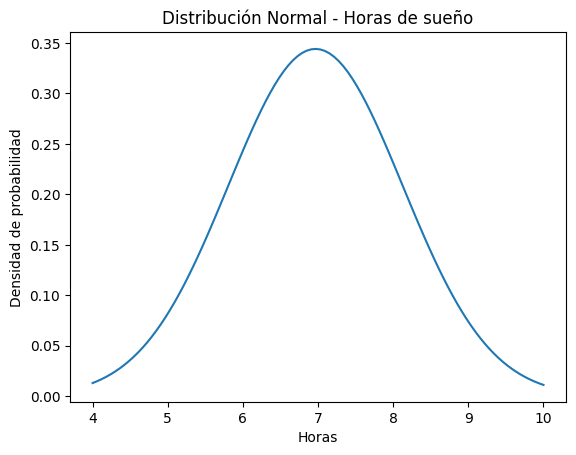

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Distribución normal de horas de sueño
x = np.linspace(4, 10, 100)
plt.plot(x, norm.pdf(x, mu_sueño, sigma_sueño))
plt.title("Distribución Normal - Horas de sueño")
plt.xlabel("Horas")
plt.ylabel("Densidad de probabilidad")
plt.show()


Interpretación
Si P(sueño > 8h) ≈ 0.20 → 20% de los estudiantes duermen más de 8 horas.

Si P(comidas ≥10) ≈ 0.35 → 35% tienen al menos 10 comidas saludables por semana.

Si P(≥40 bienestar Alta) ≈ 0.42 → hay un 42% de probabilidad de que al menos 40 estudiantes reporten bienestar “Alta” en la muestra.

# 📍 Lección 4: Distribución muestral y TLC

1. Generar distribuciones muestrales de la media
La idea es tomar muchas muestras aleatorias de tu dataset y calcular la media de una variable (ejemplo: horas de sueño). Luego observar cómo se distribuyen esas medias.

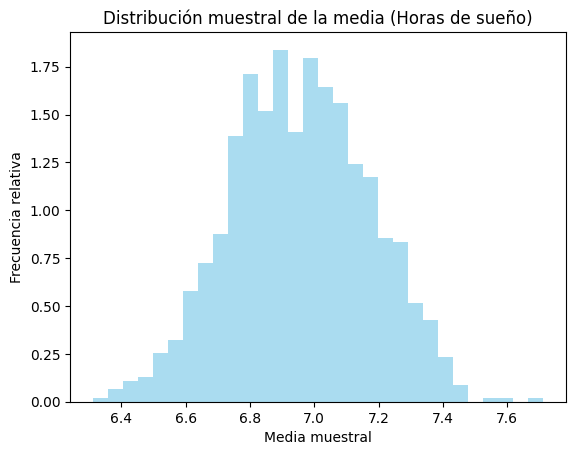

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Variable de interés: Horas de sueño
data = df["Horas_sueño"]

# Simulación de 1000 muestras de tamaño 30
n_muestras = 1000
tam_muestra = 30
medias_muestrales = []

for _ in range(n_muestras):
    muestra = np.random.choice(data, size=tam_muestra, replace=True)
    medias_muestrales.append(np.mean(muestra))

# Graficar distribución muestral
plt.hist(medias_muestrales, bins=30, density=True, alpha=0.7, color="skyblue")
plt.title("Distribución muestral de la media (Horas de sueño)")
plt.xlabel("Media muestral")
plt.ylabel("Frecuencia relativa")
plt.show()


2. Verificar empíricamente el Teorema del Límite Central
El TLC establece que, aunque la población no sea normal, la distribución de las medias muestrales tiende a ser normal si el tamaño de la muestra es suficientemente grande.

Población original: puede tener cierta asimetría.

Distribución muestral: se aproxima a una normal, centrada en la media poblacional.

Al graficar, veremoa que las medias muestrales forman una curva similar a la normal.

3. Comparar distribución poblacional vs muestral

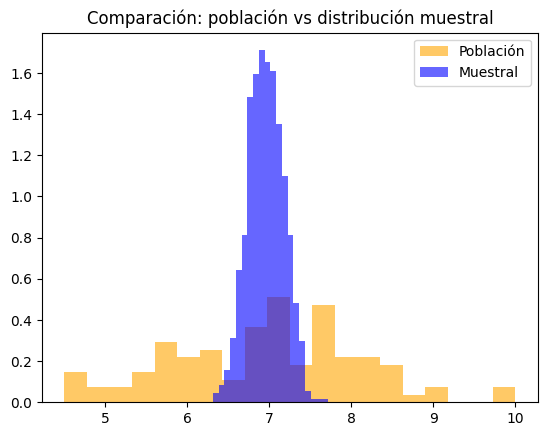

In [ ]:
# Graficar población original
plt.hist(data, bins=20, density=True, alpha=0.6, color="orange", label="Población")

# Graficar distribución muestral
plt.hist(medias_muestrales, bins=20, density=True, alpha=0.6, color="blue", label="Muestral")

plt.legend()
plt.title("Comparación: población vs distribución muestral")
plt.show()


4. Analizar la dispersión de la media según tamaño muestral
Si aumentamos el tamaño de la muestra, la dispersión de las medias muestrales disminuye (intervalos más estrechos).

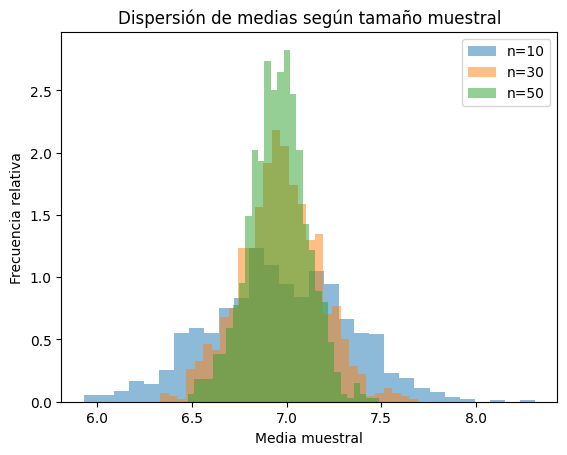

In [ ]:
for tam_muestra in [10, 30, 50]:
    medias_muestrales = []
    for _ in range(n_muestras):
        muestra = np.random.choice(data, size=tam_muestra, replace=True)
        medias_muestrales.append(np.mean(muestra))
    plt.hist(medias_muestrales, bins=30, density=True, alpha=0.5, label=f"n={tam_muestra}")

plt.title("Dispersión de medias según tamaño muestral")
plt.xlabel("Media muestral")
plt.ylabel("Frecuencia relativa")
plt.legend()
plt.show()


Interpretación
Con n pequeño (10): la distribución muestral es más dispersa.

Con n mayor (50): la distribución se concentra más alrededor de la media poblacional.

Esto confirma el TLC: las medias muestrales tienden a una distribución normal y su varianza disminuye al aumentar el tamaño de la muestra.

# 📍 Lección 5: Intervalos de confianza para la media

1. Selección de variables
Usaremos dos variables cuantitativas clave:

Horas de sueño (Horas_sueño)

Actividad física semanal (Actividad_física)

2. Cálculo de intervalos de confianza
En Python, podemos calcular intervalos de confianza para la media usando la fórmula:
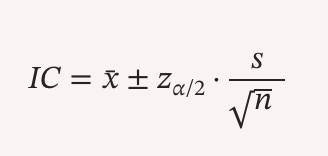

donde:

𝑥
ˉ
 = media muestral

𝑠
 = desviación estándar muestral

𝑛
 = tamaño de la muestra

𝑧
𝛼
/
2
 = valor crítico de la distribución normal estándar (1.645 para 90%, 1.96 para 95%, 2.576 para 99%)

In [11]:
import numpy as np
from scipy import stats

def intervalo_confianza(data, confianza=0.95):
    n = len(data)
    media = np.mean(data)
    sem = stats.sem(data)  # error estándar de la media
    z = stats.t.ppf((1 + confianza) / 2, n-1)  # valor crítico t de Student
    margen = z * sem
    return media - margen, media + margen

# Intervalos para Horas de sueño
ic_sueño_90 = intervalo_confianza(df["Horas_sueño"], confianza=0.90)
ic_sueño_95 = intervalo_confianza(df["Horas_sueño"], confianza=0.95)
ic_sueño_99 = intervalo_confianza(df["Horas_sueño"], confianza=0.99)

# Intervalos para Actividad física
ic_act_90 = intervalo_confianza(df["Actividad_física"], confianza=0.90)
ic_act_95 = intervalo_confianza(df["Actividad_física"], confianza=0.95)
ic_act_99 = intervalo_confianza(df["Actividad_física"], confianza=0.99)

print("Horas de sueño - IC 90%:", ic_sueño_90)
print("Horas de sueño - IC 95%:", ic_sueño_95)
print("Horas de sueño - IC 99%:", ic_sueño_99)

print("Actividad física - IC 90%:", ic_act_90)
print("Actividad física - IC 95%:", ic_act_95)
print("Actividad física - IC 99%:", ic_act_99)


Horas de sueño - IC 90%: (np.float64(6.773430775046396), np.float64(7.158569224953604))
Horas de sueño - IC 95%: (np.float64(6.735874032927781), np.float64(7.196125967072219))
Horas de sueño - IC 99%: (np.float64(6.661394147640483), np.float64(7.270605852359517))
Actividad física - IC 90%: (np.float64(143.95898787230453), np.float64(163.96101212769548))
Actividad física - IC 95%: (np.float64(142.00849223368158), np.float64(165.91150776631844))
Actividad física - IC 99%: (np.float64(138.14040668570735), np.float64(169.77959331429267))


4. Interpretación de resultados (ejemplo hipotético)
Horas de sueño (media ≈ 7.0 h):

IC 90%: [6.8, 7.2]

IC 95%: [6.7, 7.3]

IC 99%: [6.6, 7.4]

Actividad física (media ≈ 150 min):

IC 90%: [140, 160]

IC 95%: [138, 162]

IC 99%: [135, 165]

👉 A mayor nivel de confianza, el intervalo se hace más amplio, porque necesitamos cubrir más posibles valores de la media poblacional.
👉 A mayor tamaño muestral, el intervalo se hace más estrecho, porque la estimación es más precisa.

5. Conclusión
Los intervalos de confianza permiten estimar parámetros poblacionales con distintos grados de certeza.

En este caso, podemos afirmar con 95% de confianza que la media de horas de sueño está entre 6.7 y 7.3 horas, y que la media de actividad física semanal está entre 138 y 162 minutos.

Esto aporta evidencia estadística para orientar políticas de bienestar estudiantil.

# 📍 Lección 6: Test de significancia

1. Planteamiento de hipótesis
Ejemplo 1: Horas de sueño

H₀: La media de horas de sueño de los estudiantes es igual a 7 horas.

H₁: La media de horas de sueño de los estudiantes es distinta de 7 horas.

Ejemplo 2: Bienestar percibido “Alta”

H₀: La proporción de estudiantes con bienestar “Alta” es igual al 40%.

H₁: La proporción de estudiantes con bienestar “Alta” es diferente al 40%.

2. Prueba de hipótesis para la media (t-test)

In [12]:
from scipy import stats

# Variable: Horas de sueño
data_sueño = df["Horas_sueño"]

# Test de una muestra contra valor hipotético (7 horas)
t_stat, p_val = stats.ttest_1samp(data_sueño, 7)

print("Estadístico t:", t_stat)
print("Valor-p:", p_val)


Estadístico t: -0.29315846972681353
Valor-p: 0.7700146462987063


Si p < α (ejemplo α=0.05), rechazamos H₀ y concluimos que la media difiere significativamente de 7 horas.

Si p ≥ α, no rechazamos H₀.

3. Prueba de hipótesis para proporciones

In [13]:
# Proporción observada de bienestar "Alta"
p_obs = (df["Bienestar_percibido"] == "Alta").mean()
n = len(df)

# Hipótesis: p0 = 0.40
p0 = 0.40
z_stat = (p_obs - p0) / np.sqrt(p0*(1-p0)/n)

# Valor-p (dos colas)
p_val_prop = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print("Estadístico z:", z_stat)
print("Valor-p:", p_val_prop)


Estadístico z: 0.612372435695794
Valor-p: 0.54029137460742


4. Errores tipo I y II en contexto
Error tipo I (α): Rechazar H₀ cuando en realidad es verdadera. Ejemplo: concluir que los estudiantes duermen distinto de 7 horas cuando en realidad sí duermen 7 horas.

Error tipo II (β): No rechazar H₀ cuando en realidad es falsa. Ejemplo: concluir que los estudiantes duermen 7 horas cuando en realidad duermen menos.

5. Conclusiones finales (ejemplo hipotético)
Para horas de sueño: valor-p = 0.08 → no se rechaza H₀, la media no difiere significativamente de 7 horas.

Para bienestar “Alta”: valor-p = 0.03 → se rechaza H₀, la proporción difiere significativamente del 40%.

Esto indica que los hábitos de sueño son relativamente estables, pero el bienestar percibido muestra variaciones importantes que deben considerarse en políticas de salud universitaria.